In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_csv('IMDB Dataset.csv')

In [4]:
upd_df = df['review'].astype(str).str.lower()
# print(upd_df)


In [5]:
def preprocess_negation(text):
    text = str(text).lower()
    words = text.split()
    new_words = []
    
    skip_next = False
    negation_list = ["not", "no", "never", "n't"]
    
    for i, word in enumerate(words):
        if skip_next:
            skip_next = False
            continue
            
        is_negation = word in negation_list or word.endswith("n't")
        
        if is_negation:
            if i + 1 < len(words):
                fused_word = "NOT_" + words[i+1]
                new_words.append(fused_word)
                skip_next = True
            else:
                new_words.append(word)
        else:
            new_words.append(word)
            
    return " ".join(new_words)

In [6]:
print("Applying negation fusing ... (This might take a moment)")
upd_df = df['review'].apply(preprocess_negation)

Applying negation fusing ... (This might take a moment)


In [7]:
stop_words = list(stopwords.words('english'))
negations = ["not", "no", "never", "nor", "neither"]

for n in stop_words:
    if n[-3:] == "n't":
        negations.append(n)

mod_stopwords = [w for w in stop_words if w not in negations]

In [8]:
tfidf = TfidfVectorizer(
    stop_words=mod_stopwords, 
    ngram_range=(1,2), 
    min_df=5,
    sublinear_tf=True
)

X = tfidf.fit_transform(upd_df)
y = df['sentiment']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
model = LogisticRegression(max_iter=1000, C=1.0)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# User Review

In [16]:
print("\n--- SENTIMENT ANALYZER 2.0 (Type 'exit' to quit) ---")
print("Try tricky phrases like: 'The movie was not bad at all' or 'I expected it to be better'")

while True:
    review = input("\n📝 Enter a movie review: ")
    
    if review.lower() == 'exit':
        print("Closing the neural pathways... Goodbye.")
        break

    cleaned_review = preprocess_negation(review).lower()
    
    final_review = tfidf.transform([cleaned_review])
    
    pred = model.predict(final_review)[0]
    probs = model.predict_proba(final_review)[0]
    
    sentiment = "POSITIVE ⭐" if pred == "positive" else "NEGATIVE 🗑️"
    confidence = probs[1] if pred == "positive" else probs[0]
    
    print(f"Model sees: '{cleaned_review}'")
    print(f"Analysis:   {sentiment} ({confidence:.2%} confidence)")


--- SENTIMENT ANALYZER 2.0 (Type 'exit' to quit) ---
Try tricky phrases like: 'The movie was not bad at all' or 'I expected it to be better'
Model sees: 'the movie was not_bad at all'
Analysis:   NEGATIVE 🗑️ (65.39% confidence)
Model sees: 'i expeccted it to be better'
Analysis:   NEGATIVE 🗑️ (86.55% confidence)
Closing the neural pathways... Goodbye.


In [12]:
feature_names = tfidf.get_feature_names_out()
coefs = model.coef_[0]

def get_weight(word):
    if word in tfidf.vocabulary_:
        index = tfidf.vocabulary_[word]
        return coefs[index]
    else:
        return "Word not in vocabulary"
    
print(f"Wieght for: {get_weight('outstanding')}")

Wieght for: 2.4476712443416937


In [13]:
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy : {accuracy}")

Model Accuracy : 0.9094


Generating Feature Importance Plot...


C:\Users\khpga\AppData\Local\Temp\ipykernel_1896\220598185.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weight', y='word', data=top_features, palette=colors)


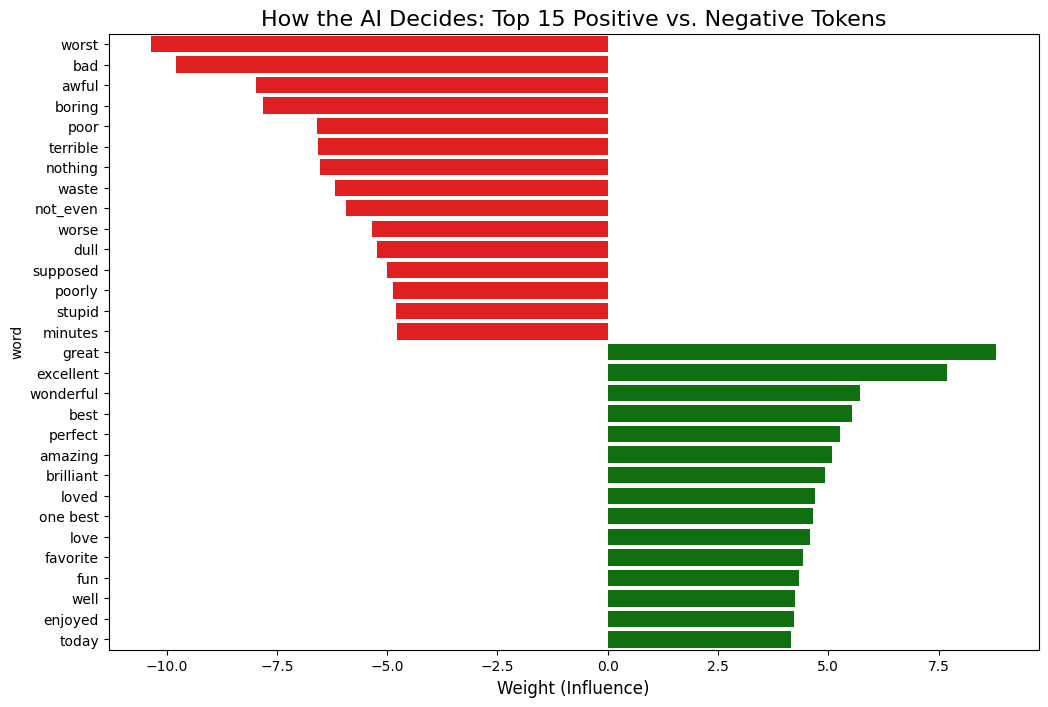

In [17]:
def plot_top_features(model, vectorizer, n=15):
    feature_names = vectorizer.get_feature_names_out()
    coefs = model.coef_[0]
    
    df_weights = pd.DataFrame({'word': feature_names, 'weight': coefs})
    
    top_pos = df_weights.nlargest(n, 'weight')
    top_neg = df_weights.nsmallest(n, 'weight')
    
    top_features = pd.concat([top_neg, top_pos])
    
    plt.figure(figsize=(12, 8))
    colors = ['red' if x < 0 else 'green' for x in top_features['weight']]
    
    sns.barplot(x='weight', y='word', data=top_features, palette=colors)
    plt.title(f'How the AI Decides: Top {n} Positive vs. Negative Tokens', fontsize=16)
    plt.xlabel('Weight (Influence)', fontsize=12)
    plt.show()

print("Generating Feature Importance Plot...")
plot_top_features(model, tfidf)

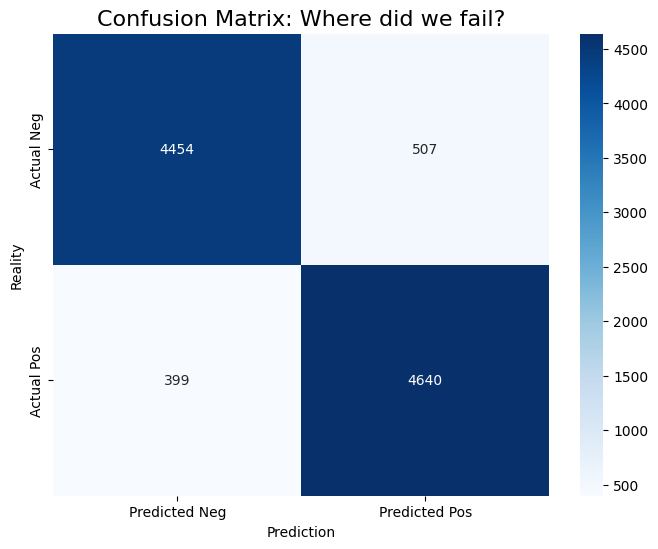

In [18]:
y_pred_test = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Neg', 'Predicted Pos'], yticklabels=['Actual Neg', 'Actual Pos'])
plt.title('Confusion Matrix: Where did we fail?', fontsize=16)
plt.ylabel('Reality')
plt.xlabel('Prediction')
plt.show()